In [1]:
import os, glob
from pathlib import Path
import pandas as pd
import openpyxl as xl

# examine sheet names
sand_xlsxs = glob.glob(os.path.join("Sketch-Sand", "*.xlsx"))
clay_xlsxs = glob.glob(os.path.join("Sketch-Clay", "*.xlsx"))

for xlsx in sand_xlsxs:
    wb = xl.load_workbook(xlsx, data_only=True)
    print(xlsx)
    print(wb.sheetnames)
    
for xlsx in clay_xlsxs:
    wb = xl.load_workbook(xlsx, data_only=True)
    print(xlsx)
    print(wb.sheetnames)

Sketch-Sand\dense_drained.xlsx
['dense_drained']
Sketch-Sand\dense_undrained.xlsx
['Dense_undrained']
Sketch-Sand\loose_drained.xlsx
['Loose_Drained']
Sketch-Sand\loose_undrained.xlsx
['loose_undrained']
Sketch-Clay\Drained clay data.xlsx
['Normally consolidated (NC)', 'Critical state (CS)', 'Overconsolidated (OC)', 'Reference lines', '2D q-p', '2D q-eax', '2D e-p', '2D du-eax']
Sketch-Clay\Undrained clay data.xlsx
['Normally consolidated (NC)', 'Critical state (CS)', 'Overconsolidated (OC)', 'Reference lines', '2D q-p', '2D q-eax', '2D e-p', '2D du-eax']


In [2]:
# load up data from each tab in each spreadsheet in the "Sketch-Sand" and "Sketch-Clay" folders
sand_data = {}
clay_data = {}

sand_labels = {
    ('Sketch-Sand\dense_drained.xlsx', 'dense_drained'): "d_d",
    ('Sketch-Sand\dense_undrained.xlsx', 'Dense_undrained'): "d_ud",
    ('Sketch-Sand\loose_drained.xlsx', 'Loose_Drained'): "l_d",
    ('Sketch-Sand\loose_undrained.xlsx', 'loose_undrained'): "l_ud"
}
clay_labels = {
    ('Sketch-Clay\Drained clay data.xlsx', 'Normally consolidated (NC)'): "nc_d",
    ('Sketch-Clay\Drained clay data.xlsx', 'Critical state (CS)'): "cs_d",
    ('Sketch-Clay\Drained clay data.xlsx', 'Overconsolidated (OC)'): "oc_d",
    ('Sketch-Clay\\Undrained clay data.xlsx', 'Normally consolidated (NC)'): "nc_ud",
    ('Sketch-Clay\\Undrained clay data.xlsx', 'Critical state (CS)'): "cs_ud",
    ('Sketch-Clay\\Undrained clay data.xlsx', 'Overconsolidated (OC)'): "oc_ud"
}

# only one sheet per spreadsheet in sands
for i, xlsx in enumerate(sand_xlsxs):
    wb = xl.load_workbook(xlsx, data_only=True)
    sheet = wb.sheetnames[0]
    
    col_headings_undrained = ["eps_ax_prc", "q_kPa", "p_kPa", "du_kPa", "e", "eta"]
    col_headings_drained = ["eps_ax_prc", "q_kPa", "p_kPa", "eps_vol_prc", "e", "eta"]
    
    sel_col_headings = col_headings_drained if "_d" in sand_labels[(xlsx, sheet)] else col_headings_undrained
    
    df = pd.read_excel(xlsx, sheet_name=sheet, skiprows=2, names=sel_col_headings)
    sel_label = sand_labels[(xlsx, sheet)]
    
    sand_data[sel_label] = df

In [3]:
# multiple sheets per spreadsheet in clays
for key, value in clay_labels.items():
    xlsx, sheet = key
    
    col_headings_undrained = ["eps_ax_prc", "q_kPa", "p_kPa", "du_kPa", "e"]
    col_headings_drained = ["eps_ax_prc", "q_kPa", "p_kPa", "eps_vol_prc", "e"]
    
    sel_col_headings = col_headings_drained if "_d" in clay_labels[(xlsx, sheet)] else col_headings_undrained
    
    df = pd.read_excel(xlsx, sheet_name=sheet, skiprows=2, names=sel_col_headings)
    sel_label = clay_labels[(xlsx, sheet)]
    clay_data[sel_label] = df

In [4]:
# for each dataframe, use pandas to linearly resample between the same start and end values, then save back to the resampled dictionaries
# resample using linear spacing

total_num = 1001

import numpy as np

linear_resampled_sand_data = {}
linear_resampled_clay_data = {}

for label, df in sand_data.items():
    eps_ax_prc_min = df["eps_ax_prc"].min()
    eps_ax_prc_max = df["eps_ax_prc"].max()
    eps_ax_prc_resampled = np.linspace(
        eps_ax_prc_min,
        eps_ax_prc_max,
        num=total_num
    )
    
    resampled_df = pd.DataFrame({"eps_ax_prc": eps_ax_prc_resampled})
    
    for col in df.columns:
        if col != "eps_ax_prc":
            resampled_df[col] = np.interp(eps_ax_prc_resampled, df["eps_ax_prc"], df[col])
    
    linear_resampled_sand_data[label] = resampled_df

for label, df in clay_data.items():
    eps_ax_prc_min = df["eps_ax_prc"].min()
    eps_ax_prc_max = df["eps_ax_prc"].max()
    eps_ax_prc_resampled = np.linspace(
        eps_ax_prc_min,
        eps_ax_prc_max,
        num=total_num
    )
    
    resampled_df = pd.DataFrame({"eps_ax_prc": eps_ax_prc_resampled})
    
    for col in df.columns:
        if col != "eps_ax_prc":
            resampled_df[col] = np.interp(eps_ax_prc_resampled, df["eps_ax_prc"], df[col])
    
    linear_resampled_clay_data[label] = resampled_df

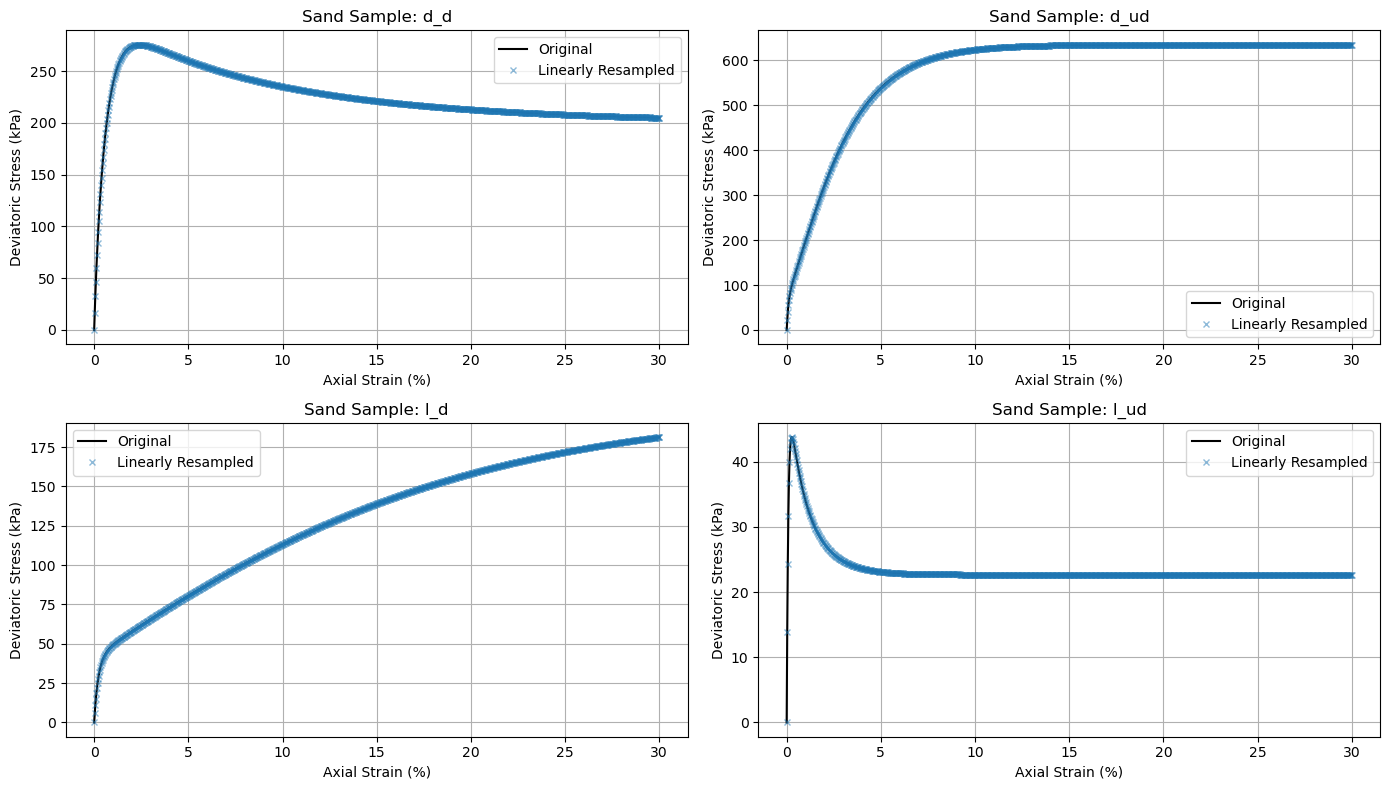

In [5]:
# plot all original vs resampled sand data as subplots in one figure
from matplotlib import pyplot as plt

n = len(sand_data)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows), squeeze=False)
axes = axes.flatten()

for ax, (label, df) in zip(axes, sand_data.items()):
    linear_resampled_df = linear_resampled_sand_data[label]
    # log_resampled_df = log_resampled_sand_data[label]
    
    ax.plot(df["eps_ax_prc"], df["q_kPa"], label="Original", ls='-', color='k')
    ax.plot(linear_resampled_df["eps_ax_prc"], linear_resampled_df["q_kPa"], label="Linearly Resampled", marker="x", ms=5, ls='', alpha=0.5)
    # ax.plot(log_resampled_df["eps_ax_prc"], log_resampled_df["q_kPa"], label="Logarithmically Resampled", marker="s", ms=5, ls='', alpha=0.5)
    
    ax.set_xlabel("Axial Strain (%)")
    ax.set_ylabel("Deviatoric Stress (kPa)")
    ax.set_title(f"Sand Sample: {label}")
    ax.grid(True)
    ax.legend()

# hide any extra axes
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


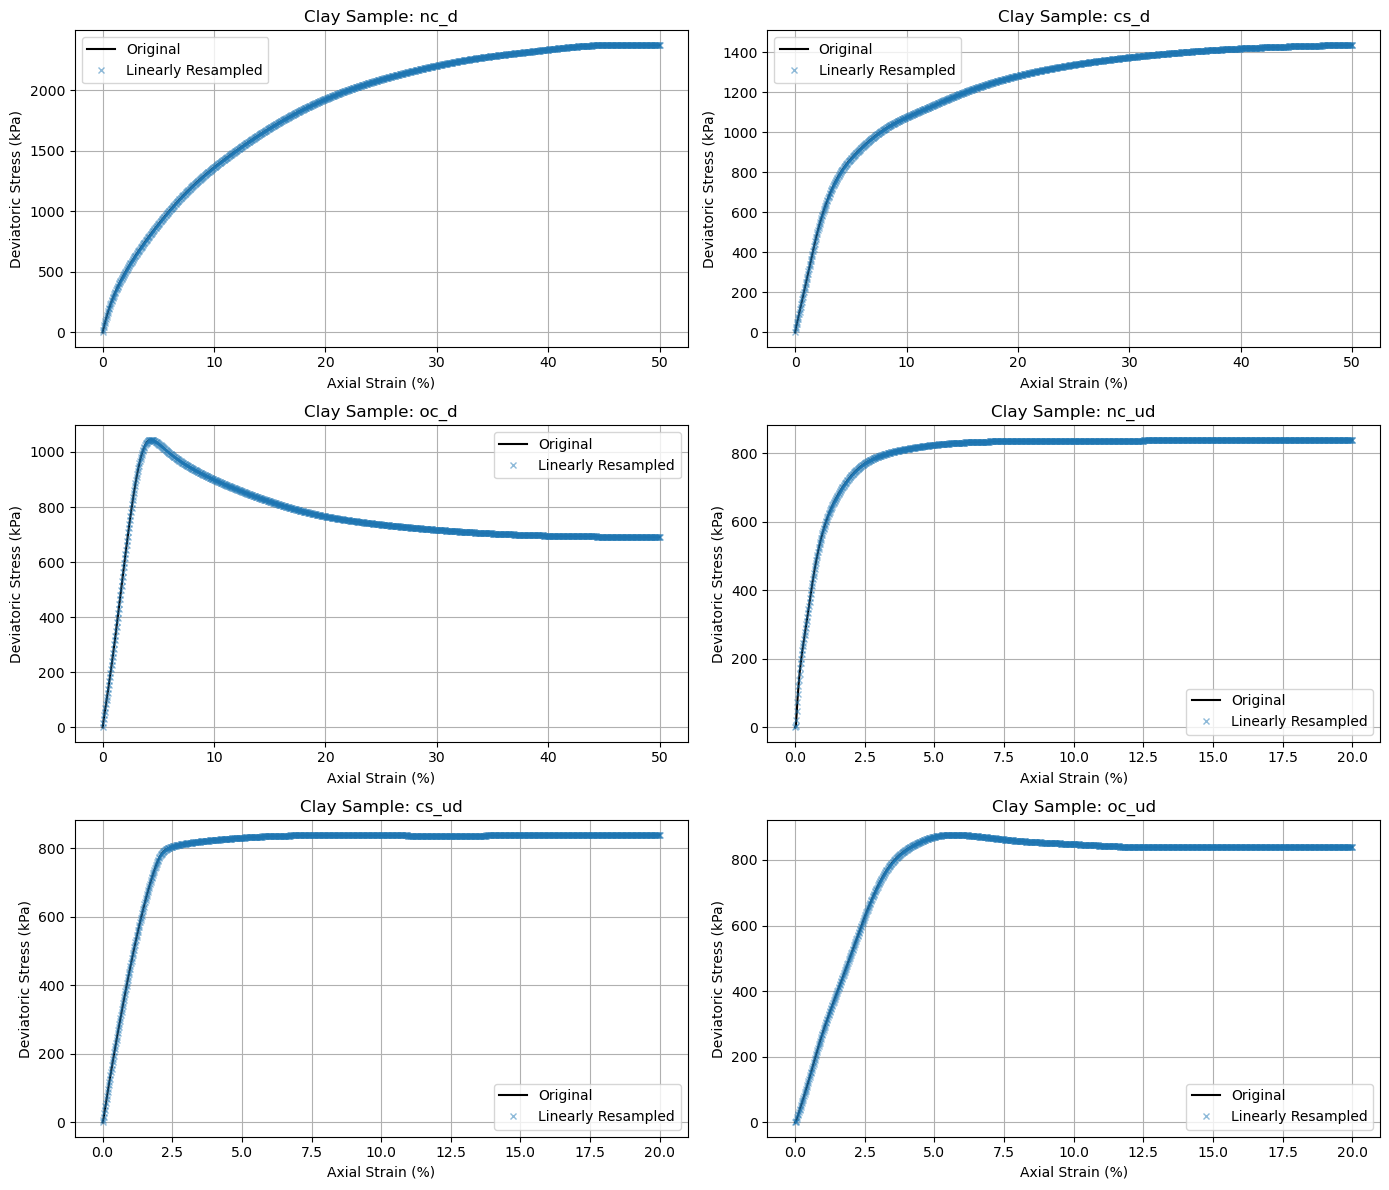

In [6]:
# plot to visualise the same for clays

# plot all original vs resampled clay data as subplots in one figure

n = len(clay_data)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows), squeeze=False)
axes = axes.flatten()

for ax, (label, df) in zip(axes, clay_data.items()):
    linear_resampled_df = linear_resampled_clay_data[label]
    # log_resampled_df = log_resampled_clay_data[label]
    
    ax.plot(df["eps_ax_prc"], df["q_kPa"], label="Original", ls='-', color='k')
    ax.plot(linear_resampled_df["eps_ax_prc"], linear_resampled_df["q_kPa"], label="Linearly Resampled", marker="x", ms=5, ls='', alpha=0.5)
    # ax.plot(log_resampled_df["eps_ax_prc"], log_resampled_df["q_kPa"], label="Logarithmically Resampled", marker="s", ms=5, ls='', alpha=0.5)
    
    ax.set_xlabel("Axial Strain (%)")
    ax.set_ylabel("Deviatoric Stress (kPa)")
    ax.set_title(f"Clay Sample: {label}")
    ax.grid(True)
    ax.legend()

# hide any extra axes
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [7]:
# write out to two spreadsheets in "resampled_data" folder, one for sands and one for clays, with each dataframe as a separate sheet
# write full length labels in sheet names

resampled_data_dir = "resampled_data"

# linear
Path(resampled_data_dir).mkdir(exist_ok=True)
with pd.ExcelWriter(os.path.join(resampled_data_dir, "linear_resampled_sand_data.xlsx")) as writer:
    for label, df in linear_resampled_sand_data.items():
        df.to_excel(writer, sheet_name=label, index=False)

with pd.ExcelWriter(os.path.join(resampled_data_dir, "linear_resampled_clay_data.xlsx")) as writer:
    for label, df in linear_resampled_clay_data.items():
        df.to_excel(writer, sheet_name=label, index=False)
        